# 01: NumPy Basics - Thinking in Matrices

## Why This Matters for ML

Everything in Machine Learning is numbers in boxes (arrays and matrices). Before we can teach a computer to understand language, we need to:

1. **Represent things as numbers** (words → numbers)
2. **Organize numbers efficiently** (arrays and matrices)
3. **Do math on them fast** (NumPy!)

### The Web Dev Analogy

Think of NumPy as the **DOM manipulation** of ML:
- Just as JavaScript lets you efficiently work with HTML elements
- NumPy lets you efficiently work with numerical data

Let's dive in!

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.style.use('seaborn-v0_8-whitegrid')
print(f"NumPy version: {np.__version__}")
print("Ready to learn! 🚀")

NumPy version: 1.26.4
Ready to learnadads! 🚀


## 1. Arrays: Lists on Steroids

Python lists are flexible but slow. NumPy arrays are fast because:
- All elements are the same type (no type checking needed)
- Stored contiguously in memory (cache-friendly)
- Operations happen in optimized C code

In [4]:
# Python list vs NumPy array
python_list = [1, 2, 3, 4, 5]
numpy_array = np.array([1, 2, 3, 4, 5])

print(f"Python list: {python_list}")
print(f"NumPy array: {numpy_array}")
print(f"\nType of python_list: {type(python_list)}")
print(f"Type of numpy_array: {type(numpy_array)}")

Python list: [1, 2, 3, 4, 5]
NumPy array: [1 2 3 4 5]

Type of python_list: <class 'list'>
Type of numpy_array: <class 'numpy.ndarray'>


In [5]:
# The speed difference is dramatic!
import time

size = 1_000_000

# Python list
py_list = list(range(size))
start = time.time()
py_result = [x * 2 for x in py_list]
py_time = time.time() - start

# NumPy array
np_array = np.arange(size)
start = time.time()
np_result = np_array * 2
np_time = time.time() - start

print(f"Python list: {py_time:.4f} seconds")
print(f"NumPy array: {np_time:.4f} seconds")
print(f"\n🚀 NumPy is {py_time/np_time:.1f}x faster!")

Python list: 0.0455 seconds
NumPy array: 0.0032 seconds

🚀 NumPy is 14.4x faster!


## 2. Creating Arrays

NumPy gives us many ways to create arrays. Here are the most common:

In [6]:
# From a list
a = np.array([1, 2, 3])
print(f"From list: {a}")

# Zeros and ones (very common for initialization)
zeros = np.zeros(5)
ones = np.ones(5)
print(f"\nZeros: {zeros}")
print(f"Ones: {ones}")

# Range of numbers
range_arr = np.arange(0, 10, 2)  # start, stop, step
print(f"\nRange (0 to 10, step 2): {range_arr}")

# Evenly spaced numbers
linspace = np.linspace(0, 1, 5)  # 5 numbers between 0 and 1
print(f"Linspace (5 numbers 0 to 1): {linspace}")

# Random numbers (super important for ML!)
random_arr = np.random.randn(5)  # random numbers from normal distribution
print(f"\nRandom (normal dist): {random_arr}")

From list: [1 2 3]

Zeros: [0. 0. 0. 0. 0.]
Ones: [1. 1. 1. 1. 1.]

Range (0 to 10, step 2): [0 2 4 6 8]
Linspace (5 numbers 0 to 1): [0.   0.25 0.5  0.75 1.  ]

Random (normal dist): [ 1.0412696  -1.12391581  1.01058495  1.27481219 -1.15210749]


## 3. Shape: The Structure of Data

**Shape** is one of the most important concepts in ML. It tells you the structure of your data.

Think of it like:
- **1D array (vector)**: A single row of numbers → `shape = (n,)`
- **2D array (matrix)**: Rows and columns → `shape = (rows, cols)`
- **3D array (tensor)**: Stack of matrices → `shape = (depth, rows, cols)`

In [7]:
# 1D: Vector (like a single sentence's features)
vector = np.array([1, 2, 3, 4, 5])
print(f"1D Vector: {vector}")
print(f"Shape: {vector.shape}")

# 2D: Matrix (like a batch of sentences)
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
print(f"\n2D Matrix:\n{matrix}")
print(f"Shape: {matrix.shape}  # (rows, columns)")

# 3D: Tensor (like a batch of documents, each with multiple sentences)
tensor = np.array([
    [[1, 2], [3, 4]],
    [[5, 6], [7, 8]]
])
print(f"\n3D Tensor:\n{tensor}")
print(f"Shape: {tensor.shape}  # (depth, rows, columns)")

1D Vector: [1 2 3 4 5]
Shape: (5,)

2D Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)  # (rows, columns)

3D Tensor:
[[[1 2]
  [3 4]]

 [[5 6]
  [7 8]]]
Shape: (2, 2, 2)  # (depth, rows, columns)


### 🔑 Key Insight: NLP Data Shapes

In NLP, you'll often see shapes like:
- `(batch_size, sequence_length)` - batch of tokenized sentences
- `(batch_size, sequence_length, embedding_dim)` - batch of embedded sentences

Don't worry if this doesn't click yet - it will!

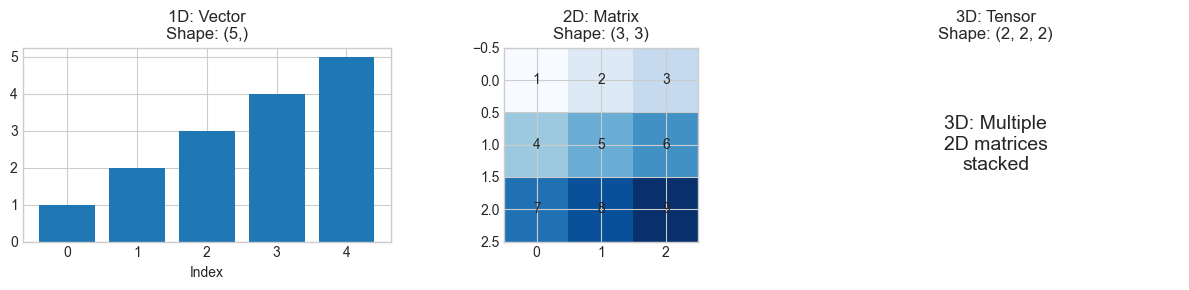

In [8]:
# Visualizing shapes
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# 1D
axes[0].bar(range(5), [1, 2, 3, 4, 5])
axes[0].set_title('1D: Vector\nShape: (5,)')
axes[0].set_xlabel('Index')

# 2D
axes[1].imshow(matrix, cmap='Blues')
axes[1].set_title('2D: Matrix\nShape: (3, 3)')
for i in range(3):
    for j in range(3):
        axes[1].text(j, i, matrix[i, j], ha='center', va='center')

# 3D visualization hint
axes[2].text(0.5, 0.5, '3D: Multiple\n2D matrices\nstacked', 
             ha='center', va='center', fontsize=14,
             transform=axes[2].transAxes)
axes[2].set_title('3D: Tensor\nShape: (2, 2, 2)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 4. Reshaping: Molding Your Data

Often you need to change the shape of your data without changing the values. This is called **reshaping**.

In [9]:
# Start with a 1D array
arr = np.arange(12)
print(f"Original: {arr}")
print(f"Shape: {arr.shape}")

# Reshape to 2D (3 rows, 4 columns)
reshaped = arr.reshape(3, 4)
print(f"\nReshaped to (3, 4):\n{reshaped}")

# Reshape to different 2D (4 rows, 3 columns)
reshaped2 = arr.reshape(4, 3)
print(f"\nReshaped to (4, 3):\n{reshaped2}")

# Use -1 to auto-calculate one dimension
auto_reshape = arr.reshape(2, -1)  # 2 rows, auto-calculate columns
print(f"\nReshaped to (2, -1) → (2, 6):\n{auto_reshape}")

Original: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape: (12,)

Reshaped to (3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Reshaped to (4, 3):
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]

Reshaped to (2, -1) → (2, 6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


### ⚠️ Common Error: Shape Mismatch

You can only reshape if the total number of elements matches!

In [10]:
# This will fail - 12 elements can't fit into (3, 5) = 15 slots
try:
    bad_reshape = arr.reshape(3, 5)
except ValueError as e:
    print(f"❌ Error: {e}")
    print(f"\n12 elements cannot reshape to (3, 5) because 3×5 = 15 ≠ 12")

❌ Error: cannot reshape array of size 12 into shape (3,5)

12 elements cannot reshape to (3, 5) because 3×5 = 15 ≠ 12


## 5. Indexing and Slicing

Accessing parts of arrays is crucial. NumPy indexing is powerful but can be confusing at first.

In [11]:
# Create a sample matrix
matrix = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12]
])
print(f"Matrix:\n{matrix}\n")

# Single element: [row, column]
print(f"Element at [1, 2]: {matrix[1, 2]}  # row 1, column 2")

# Entire row
print(f"Row 0: {matrix[0]}")
print(f"Row 0 (explicit): {matrix[0, :]}")

# Entire column
print(f"Column 1: {matrix[:, 1]}")

# Slice: rows 0-1, columns 1-3
print(f"\nSlice [0:2, 1:3]:\n{matrix[0:2, 1:3]}")

Matrix:
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Element at [1, 2]: 7  # row 1, column 2
Row 0: [1 2 3 4]
Row 0 (explicit): [1 2 3 4]
Column 1: [ 2  6 10]

Slice [0:2, 1:3]:
[[2 3]
 [6 7]]


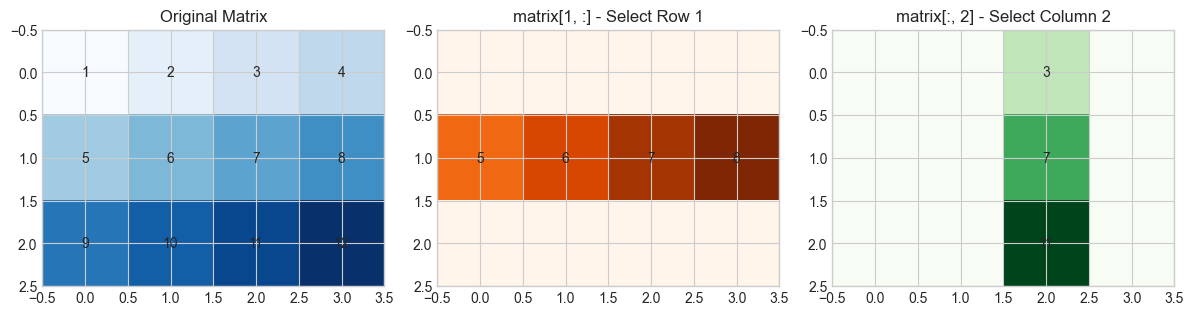

In [12]:
# Visual representation of slicing
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# Original matrix
axes[0].imshow(matrix, cmap='Blues')
axes[0].set_title('Original Matrix')
for i in range(3):
    for j in range(4):
        axes[0].text(j, i, matrix[i, j], ha='center', va='center')

# Row selection
row_select = np.zeros_like(matrix)
row_select[1] = matrix[1]
axes[1].imshow(row_select, cmap='Oranges')
axes[1].set_title('matrix[1, :] - Select Row 1')
for i in range(3):
    for j in range(4):
        axes[1].text(j, i, matrix[i, j] if i == 1 else '', ha='center', va='center')

# Column selection
col_select = np.zeros_like(matrix)
col_select[:, 2] = matrix[:, 2]
axes[2].imshow(col_select, cmap='Greens')
axes[2].set_title('matrix[:, 2] - Select Column 2')
for i in range(3):
    for j in range(4):
        axes[2].text(j, i, matrix[i, j] if j == 2 else '', ha='center', va='center')

plt.tight_layout()
plt.show()

## 6. Broadcasting: NumPy's Superpower

Broadcasting lets NumPy do operations between arrays of different shapes. It's like automatic expansion.

**Rule**: NumPy compares shapes element-wise from right to left. Dimensions are compatible if:
1. They're equal, OR
2. One of them is 1

In [13]:
# Scalar broadcasting (simplest case)
arr = np.array([1, 2, 3, 4, 5])
print(f"Array: {arr}")
print(f"Array + 10: {arr + 10}")
print(f"Array * 2: {arr * 2}")

Array: [1 2 3 4 5]
Array + 10: [11 12 13 14 15]
Array * 2: [ 2  4  6  8 10]


In [14]:
# More interesting: matrix + vector
matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
row_vector = np.array([10, 20, 30])

print(f"Matrix (3x3):\n{matrix}\n")
print(f"Row vector (3,): {row_vector}\n")
print(f"Matrix + Row vector:\n{matrix + row_vector}")
print("\n→ The vector was 'broadcast' to each row!")

Matrix (3x3):
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Row vector (3,): [10 20 30]

Matrix + Row vector:
[[11 22 33]
 [14 25 36]
 [17 28 39]]

→ The vector was 'broadcast' to each row!


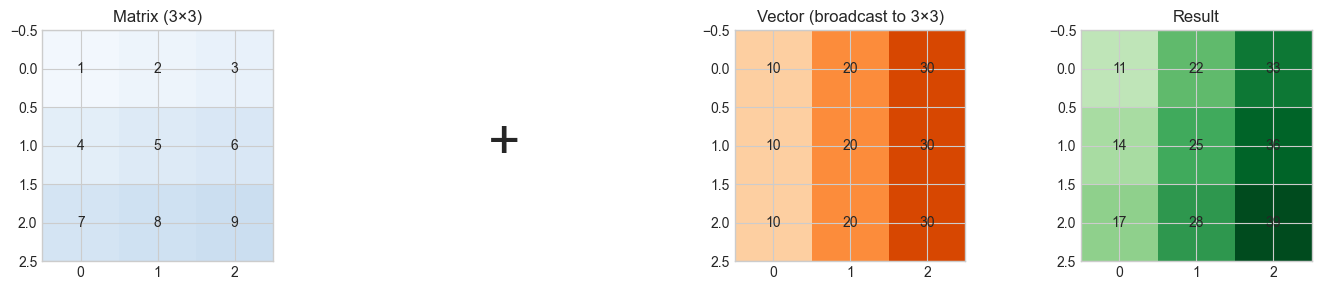

In [15]:
# Visualize broadcasting
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

# Original matrix
axes[0].imshow(matrix, cmap='Blues', vmin=0, vmax=40)
axes[0].set_title('Matrix (3×3)')
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, matrix[i, j], ha='center', va='center')

# Plus sign
axes[1].text(0.5, 0.5, '+', fontsize=40, ha='center', va='center')
axes[1].axis('off')

# Vector (broadcast visualization)
broadcast_viz = np.tile(row_vector, (3, 1))
axes[2].imshow(broadcast_viz, cmap='Oranges', vmin=0, vmax=40)
axes[2].set_title('Vector (broadcast to 3×3)')
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, row_vector[j], ha='center', va='center')

# Result
result = matrix + row_vector
axes[3].imshow(result, cmap='Greens', vmin=0, vmax=40)
axes[3].set_title('Result')
for i in range(3):
    for j in range(3):
        axes[3].text(j, i, result[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

## 7. Essential Operations for ML

These operations come up constantly in Machine Learning:

In [16]:
# Sample data
data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
print(f"Data:\n{data}\n")

# Sum, mean, std
print(f"Sum of all: {data.sum()}")
print(f"Mean of all: {data.mean()}")
print(f"Std of all: {data.std():.2f}")

# Along specific axes
print(f"\nSum along rows (axis=1): {data.sum(axis=1)}")
print(f"Sum along columns (axis=0): {data.sum(axis=0)}")
print(f"\nMean along rows: {data.mean(axis=1)}")
print(f"Mean along columns: {data.mean(axis=0)}")

Data:
[[1 2 3]
 [4 5 6]
 [7 8 9]]

Sum of all: 45
Mean of all: 5.0
Std of all: 2.58

Sum along rows (axis=1): [ 6 15 24]
Sum along columns (axis=0): [12 15 18]

Mean along rows: [2. 5. 8.]
Mean along columns: [4. 5. 6.]


In [17]:
# Matrix multiplication - THE most important operation in ML!
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print(f"Matrix A:\n{A}\n")
print(f"Matrix B:\n{B}\n")

# Element-wise multiplication (NOT what we usually want)
print(f"Element-wise (A * B):\n{A * B}\n")

# Matrix multiplication (THIS is what we want)
print(f"Matrix multiplication (A @ B):\n{A @ B}")
print(f"Same as np.dot(A, B):\n{np.dot(A, B)}")

Matrix A:
[[1 2]
 [3 4]]

Matrix B:
[[5 6]
 [7 8]]

Element-wise (A * B):
[[ 5 12]
 [21 32]]

Matrix multiplication (A @ B):
[[19 22]
 [43 50]]
Same as np.dot(A, B):
[[19 22]
 [43 50]]


### 🔑 Why Matrix Multiplication Matters

In neural networks:
- **Input**: Your data (e.g., word representations)
- **Weights**: What the network learns
- **Output = Input @ Weights**: The transformation!

Every neural network layer is essentially a matrix multiplication + some extras.

In [18]:
# Simulating a neural network layer
np.random.seed(42)

# Input: 3 samples, each with 4 features
inputs = np.random.randn(3, 4)
print(f"Inputs (3 samples × 4 features):\n{inputs.round(2)}\n")

# Weights: transform 4 features → 2 features
weights = np.random.randn(4, 2)
print(f"Weights (4 → 2):\n{weights.round(2)}\n")

# Output: 3 samples, each with 2 features
output = inputs @ weights
print(f"Output (3 samples × 2 features):\n{output.round(2)}")
print(f"\nShape: {inputs.shape} @ {weights.shape} = {output.shape}")

Inputs (3 samples × 4 features):
[[ 0.5  -0.14  0.65  1.52]
 [-0.23 -0.23  1.58  0.77]
 [-0.47  0.54 -0.46 -0.47]]

Weights (4 → 2):
[[ 0.24 -1.91]
 [-1.72 -0.56]
 [-1.01  0.31]
 [-0.91 -1.41]]

Output (3 samples × 2 features):
[[-1.68 -2.82]
 [-1.95 -0.01]
 [-0.16  1.11]]

Shape: (3, 4) @ (4, 2) = (3, 2)


## 8. NLP Preview: Words as Numbers

Let's see why all this matters for NLP. We need to represent text as numbers!

In [19]:
# Simple vocabulary
vocab = ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'ran']
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
print(f"Vocabulary: {vocab}")
print(f"Word to index: {word_to_idx}")

Vocabulary: ['the', 'cat', 'sat', 'on', 'mat', 'dog', 'ran']
Word to index: {'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4, 'dog': 5, 'ran': 6}


In [20]:
# One-hot encoding: each word as a vector
def one_hot(word, vocab):
    """Convert a word to a one-hot vector."""
    vec = np.zeros(len(vocab))
    if word in word_to_idx:
        vec[word_to_idx[word]] = 1
    return vec

# Encode some words
for word in ['cat', 'dog', 'mat']:
    vec = one_hot(word, vocab)
    print(f"{word:5} → {vec}")

cat   → [0. 1. 0. 0. 0. 0. 0.]
dog   → [0. 0. 0. 0. 0. 1. 0.]
mat   → [0. 0. 0. 0. 1. 0. 0.]


Sentence: 'the cat sat on the mat'

As matrix (shape (6, 7)):
[[1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 1 0 0]]


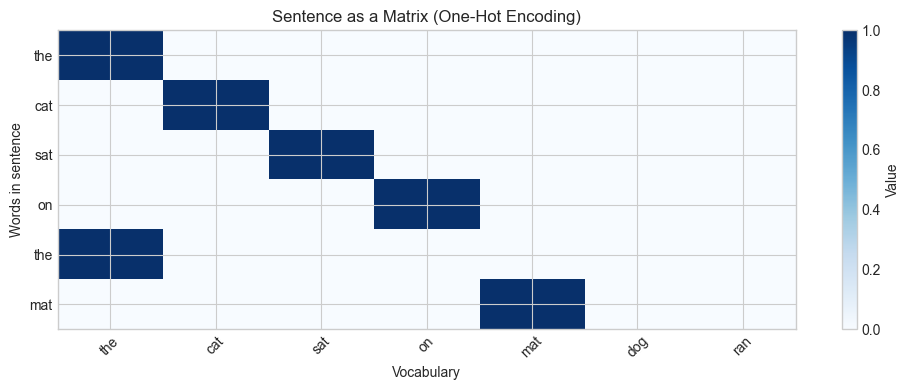

In [21]:
# A sentence becomes a matrix!
sentence = "the cat sat on the mat"
words = sentence.split()

# Each row is a word's one-hot encoding
sentence_matrix = np.array([one_hot(word, vocab) for word in words])

print(f"Sentence: '{sentence}'")
print(f"\nAs matrix (shape {sentence_matrix.shape}):")
print(sentence_matrix.astype(int))

# Visualize
plt.figure(figsize=(10, 4))
plt.imshow(sentence_matrix, cmap='Blues', aspect='auto')
plt.xticks(range(len(vocab)), vocab, rotation=45)
plt.yticks(range(len(words)), words)
plt.xlabel('Vocabulary')
plt.ylabel('Words in sentence')
plt.title('Sentence as a Matrix (One-Hot Encoding)')
plt.colorbar(label='Value')
plt.tight_layout()
plt.show()

### The Problem with One-Hot Encoding

Notice that:
- 'cat' and 'dog' look equally different from each other as 'cat' and 'the'
- No notion of similarity is captured
- Vectors are huge for real vocabularies (50,000+ words!)

**This is why we need embeddings** (Module 5) - but first, we need to understand the basics!

## 📝 Check Your Understanding

1. What's the shape of a matrix with 5 rows and 3 columns?
2. Can you reshape a (12,) array into (3, 5)? Why or why not?
3. What does `matrix[:, 0]` select?
4. What's the difference between `*` and `@` for matrices?
5. Why is one-hot encoding inefficient for large vocabularies?

In [ ]:
# Your turn! Try some exercises:

# Exercise 1: Create a 4x4 identity matrix (1s on diagonal, 0s elsewhere)
# Hint: Use np.eye()
identity = None  # Your code here

# Exercise 2: Create a sentence matrix for "the dog ran"
sentence2 = "the dog ran"
sentence2_matrix = None  # Your code here

# Exercise 3: What's the mean of each row in sentence_matrix?
row_means = None  # Your code here

## 🎯 Summary

You learned:
- **Arrays** are faster than Python lists
- **Shape** describes the structure of your data
- **Reshaping** molds data without changing values
- **Broadcasting** lets you do operations between different shapes
- **Matrix multiplication** is the heart of neural networks
- **One-hot encoding** turns words into numbers (but has limitations)

**Next up**: Understanding data - features, labels, and distributions! →